# Reciprocal Connectivity Analysis: High vs Low Myelin Groups

This notebook analyzes reciprocal connectivity patterns between neurons with high vs low myelin coverage.

In [2]:
from caveclient import CAVEclient
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Initialize CAVE client
client = CAVEclient('minnie65_public')
client.version = 1507  # set materialization version for consistency

print(f"Using CAVE client version: {client.version}")

Using CAVE client version: 1507


## Load Myelin Data and Create Groups

In [88]:
# Load myelin info dataframe
myelin_df = pd.read_csv('/Users/artliang/Documents/Myelin Plasticity/Myelin_Extract/myelin_info_df (4).csv')
# Remove rows with unwanted cell types
# excluded_types = ['MC', 'BC', 'BPC']
# myelin_df = myelin_df[~myelin_df['cell_type'].isin(excluded_types)].reset_index(drop=True)
# print(f"Loaded {len(myelin_df)} neurons with myelin data after removing cell types {excluded_types}")
print(f"\nColumns: {list(myelin_df.columns)}")
print(f"\nMyelin length statistics:")
print(myelin_df['total_myelin_length'].describe())

# inhibitory_types = ['BC', 'MC', 'BPC']
# myelin_df = myelin_df[~myelin_df['cell_type'].isin(inhibitory_types)].copy()

# -- ADD: Myelination summary and statistics for key cell types --
cell_type_order = ['23P', '4P', '5P-IT', 'BC']

# Count total cells and myelinated cells for each type
summary = []
for ct in cell_type_order:
    cells = myelin_df[myelin_df['cell_type'] == ct]
    n_total = len(cells)
    n_myelinated = (cells['total_myelin_length'] > 0).sum()
    # stats only on myelinated cells
    myel_lengths = cells.loc[cells['total_myelin_length'] > 0, 'total_myelin_length']
    mean = myel_lengths.mean()
    std = myel_lengths.std()
    summary.append({
        'cell_type': ct,
        'n_myelinated': n_myelinated,
        'n_total': n_total,
        'fraction_myelinated': f"{n_myelinated}/{n_total}",
        'mean': mean,
        'std': std,
    })

print("\nFraction of cells that are myelinated (total myelinated/total):")
for s in summary:
    print(f"{s['cell_type']}: {s['fraction_myelinated']}")

print("\nAmong myelinated neurons, total myelin length per cell type (mean ± SD in μm):")
for s in summary:
    if not np.isnan(s['mean']):
        print(f"{s['cell_type']}: {s['mean']:.1f} ± {s['std']:.1f} μm")
    else:
        print(f"{s['cell_type']}: N/A (no myelinated cells)")

myelin_df.head(10)


Columns: ['pt_root_id', 'total_myelin_length', 'cell_type', 'number_of_segments']

Myelin length statistics:
count     804.000000
mean      283.825087
std       409.696040
min         0.000000
25%         2.302500
50%       146.325000
75%       404.810000
max      3364.970000
Name: total_myelin_length, dtype: float64

Fraction of cells that are myelinated (total myelinated/total):
23P: 203/252
4P: 136/219
5P-IT: 144/170
BC: 34/35

Among myelinated neurons, total myelin length per cell type (mean ± SD in μm):
23P: 306.2 ± 260.2 μm
4P: 274.9 ± 313.7 μm
5P-IT: 393.2 ± 290.6 μm
BC: 837.1 ± 1035.7 μm


,pt_root_id,total_myelin_length,cell_type,number_of_segments
0,864691135739733140,221.03,4P,29
1,864691136041000190,0.00,6P-IT,63
2,864691135938604804,279.49,23P,104
3,864691136578982164,0.00,4P,69
4,864691135209715577,0.00,6P-IT,9
5,864691134949263100,130.05,5P-IT,90
6,864691135700409211,266.10,4P,88
7,864691136176327430,58.77,23P,41
8,864691136313301565,490.47,4P,86
9,864691135417236410,712.50,23P,64


Median myelin length: 146.32 μm

Group sizes:
myelin_group
high_myelin    402
low_myelin     402
Name: count, dtype: int64

High myelin group - mean: 536.38 μm
Low myelin group - mean: 31.27 μm


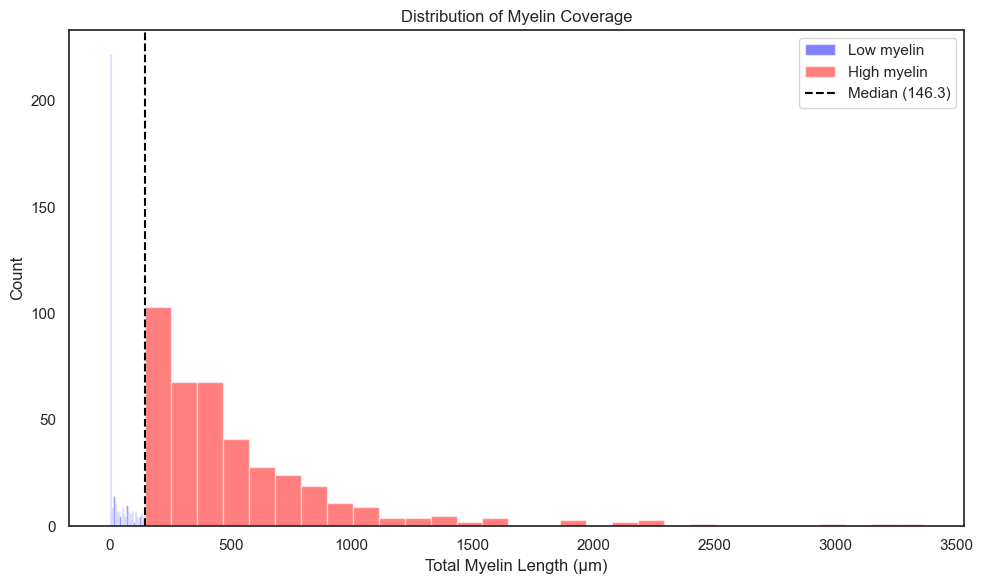

In [89]:
# Create high and low myelin groups using median split
median_myelin = myelin_df['total_myelin_length'].median()
print(f"Median myelin length: {median_myelin:.2f} μm")

# Assign groups
myelin_df['myelin_group'] = myelin_df['total_myelin_length'].apply(
    lambda x: 'high_myelin' if x >= median_myelin else 'low_myelin'
)

# Display group statistics
print(f"\nGroup sizes:")
print(myelin_df['myelin_group'].value_counts())

print(f"\nHigh myelin group - mean: {myelin_df[myelin_df['myelin_group']=='high_myelin']['total_myelin_length'].mean():.2f} μm")
print(f"Low myelin group - mean: {myelin_df[myelin_df['myelin_group']=='low_myelin']['total_myelin_length'].mean():.2f} μm")

# Plot distribution
fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(myelin_df[myelin_df['myelin_group']=='low_myelin']['total_myelin_length'], 
        alpha=0.5, bins=30, label='Low myelin', color='blue')
ax.hist(myelin_df[myelin_df['myelin_group']=='high_myelin']['total_myelin_length'], 
        alpha=0.5, bins=30, label='High myelin', color='red')
ax.axvline(median_myelin, color='black', linestyle='--', label=f'Median ({median_myelin:.1f})')
ax.set_xlabel('Total Myelin Length (μm)')
ax.set_ylabel('Count')
ax.set_title('Distribution of Myelin Coverage')
ax.legend()
plt.tight_layout()
plt.show()

Average myelin length (μm) by cell type (ordered):
cell_type
23P      246.689683
4P       170.723379
5P-IT    333.024471
BC       813.216286
Name: total_myelin_length, dtype: float64


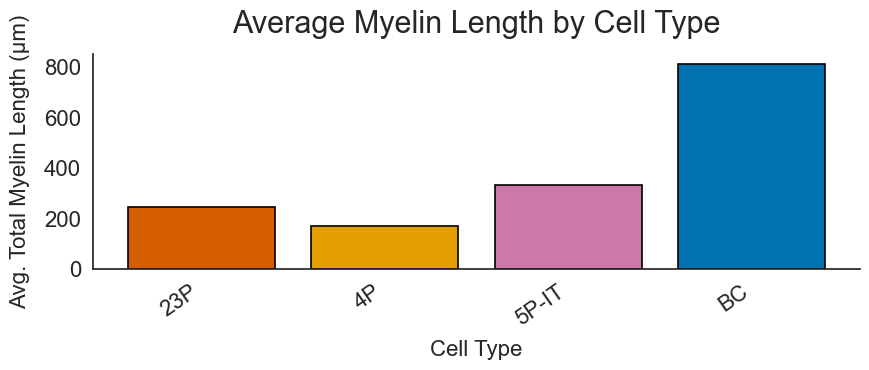

In [90]:
# Bar plot: mean myelin length by cell type, publication colors, tighter & bigger font

import seaborn as sns

cell_type_order = ['23P', '4P', '5P-IT', 'BC']
cell_type_colors = {
    '23P': '#D55E00',
    '4P': '#E69F00',
    '5P-IT': '#CC79A7',
    'BC': '#0072B2'
}

mean_myelin_by_type = myelin_df.groupby('cell_type')['total_myelin_length'].mean()
present_cell_types = [ct for ct in cell_type_order if ct in mean_myelin_by_type.index]
mean_myelin_by_type = mean_myelin_by_type.loc[present_cell_types]

print("Average myelin length (μm) by cell type (ordered):")
print(mean_myelin_by_type)

bar_colors = [cell_type_colors[ct] for ct in mean_myelin_by_type.index]

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(
    mean_myelin_by_type.index, mean_myelin_by_type.values,
    color=bar_colors, edgecolor='black', linewidth=1.2
)

title_size = 22
axis_label_size = 16
tick_size = 16

ax.set_xlabel('Cell Type', fontsize=axis_label_size, labelpad=8)
ax.set_ylabel('Avg. Total Myelin Length (μm)', fontsize=axis_label_size, labelpad=10)
ax.set_title('Average Myelin Length by Cell Type', fontsize=title_size, pad=15)

plt.xticks(rotation=35, ha='right', fontsize=tick_size)
plt.yticks(fontsize=tick_size)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(axis='both', which='major', length=5, width=1)

plt.tight_layout(pad=1.5)
plt.show()

/var/folders/20/sydjdg052fld_b2zzxcwvf540000gn/T/ipykernel_30538/964477401.py:81: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


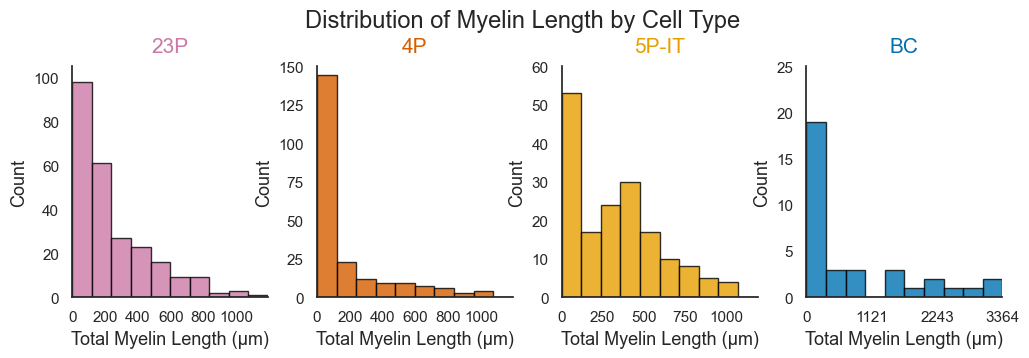

In [107]:
import seaborn as sns
import matplotlib.pyplot as plt

cell_type_order = ['23P', '4P', '5P-IT', 'BC']
cell_type_colors = {
    '23P': '#CC79A7',
    '4P': '#D55E00',
    '5P-IT': '#E69F00',
    'BC': '#0072B2'
}

# Filter for just the cell types we want, drop NaNs, and only include neurons with myelin (total_myelin_length > 0)
myelin_hist_df = myelin_df[
    (myelin_df['cell_type'].isin(cell_type_order))
].copy()
myelin_hist_df = myelin_hist_df.dropna(subset=['total_myelin_length'])

# Custom bin settings for each type to separate out BCs (who have much larger values)
bc_max = myelin_hist_df[myelin_hist_df['cell_type'] == 'BC']['total_myelin_length'].max()
other_max = myelin_hist_df[myelin_hist_df['cell_type'] != 'BC']['total_myelin_length'].quantile(0.99)
bc_bins = 10
other_bins = 10

fig, axes = plt.subplots(
    nrows=1, ncols=4, 
    figsize=(12, 3), 
    sharey=False,  # <-- No shared y-axis
    gridspec_kw={'wspace': 0.25}
)

for i, (ax, cell_type) in enumerate(zip(axes, cell_type_order)):
    sub_df = myelin_hist_df[myelin_hist_df['cell_type'] == cell_type]
    color = cell_type_colors[cell_type]
    
    if cell_type == 'BC':
        bins = bc_bins
        max_x = bc_max
    else:
        bins = other_bins
        max_x = other_max

    n_counts, *_ = ax.hist(
        sub_df['total_myelin_length'],
        bins=bins,
        range=(0, max_x),
        color=color,
        edgecolor='black',
        alpha=0.80
    )

    # y-label for counts ON for all subplots
    ax.set_ylabel("Count", fontsize=13)

    # Title as cell type
    ax.set_title(cell_type, fontsize=15, color=color, pad=10)
    sns.despine(ax=ax, left=False, bottom=False)
    ax.set_xlim(0, max_x)
    # Set each subplot's y-limit individually so tallest bar is seen
    y_max = max(5, int((max(n_counts) + 2)//5 * 5 + 5)) # round up to next 5
    ax.set_ylim(0, y_max)
    ax.tick_params(axis='y', labelsize=11)

    # Different x ticks per cell type for clarity
    if cell_type == "BC":
        xticks = [0, int(max_x/3), int(2*max_x/3), int(max_x)]
    elif cell_type == "5P-IT":
        xticks = list(range(0, int(max_x)+1, 250))
    elif cell_type == "4P":
        xticks = list(range(0, int(max_x)+1, 200))
    elif cell_type == "23P":
        xticks = list(range(0, int(max_x)+1, 200))
    else:
        xticks = ax.get_xticks()
    ax.set_xticks(xticks)
    ax.set_xticklabels([f"{int(tick)}" for tick in xticks], fontsize=11)

    # Only bottom axes get xlabel for neatness
    ax.set_xlabel("Total Myelin Length (μm)", fontsize=13)
    
fig.suptitle('Distribution of Myelin Length by Cell Type', fontsize=17, y=1.07)
plt.tight_layout()
plt.show()

## Pull Connectivity Data

In [ ]:
%%time
# Query synapses between neurons in our myelin dataset
neuron_ids = myelin_df['pt_root_id'].tolist()
print(f"Querying synapses for {len(neuron_ids)} neurons...")

syn_df = client.materialize.synapse_query(
    pre_ids=neuron_ids,
    post_ids=neuron_ids,
    remove_autapses=True,
)

print(f"Found {len(syn_df)} synapses")
syn_df.head()

Querying synapses for 804 neurons...


HTTPError: 500 Server Error: INTERNAL SERVER ERROR for url: https://minnie.microns-daf.com/materialize/api/v3/datastack/minnie65_public/version/1507/table/synapses_pni_2/query?return_pyarrow=True&split_positions=True content:b'{"code": 500, "message": "module \'pyarrow\' has no attribute \'default_serialization_context\'", "traceback": ["Traceback (most recent call last):\\n", "  File \\"/usr/local/lib/python3.12/site-packages/flask/app.py\\", line 1484, in full_dispatch_request\\n    rv = self.dispatch_request()\\n         ^^^^^^^^^^^^^^^^^^^^^^^\\n", "  File \\"/usr/local/lib/python3.12/site-packages/flask/app.py\\", line 1469, in dispatch_request\\n    return self.ensure_sync(self.view_functions[rule.endpoint])(**view_args)\\n           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^\\n", "  File \\"/usr/local/lib/python3.12/site-packages/flask_restx/api.py\\", line 402, in wrapper\\n    resp = resource(*args, **kwargs)\\n           ^^^^^^^^^^^^^^^^^^^^^^^^^\\n", "

In [5]:
import pandas as pd
syn_df = pd.read_csv("syn_df.csv")

In [4]:
# Load synapse dataframe from pickle
import pandas as pd

syn_df = pd.read_pickle("syn_df.pkl")

ModuleNotFoundError: No module named 'numpy._core'

In [50]:
# Compute synapse counts per connection
syn_weights_df = syn_df.groupby(
    ['pre_pt_root_id', 'post_pt_root_id']
).size().reset_index(name='syn_count')

print(f"Total connections: {len(syn_weights_df)}")
print(f"Mean synapses per connection: {syn_weights_df['syn_count'].mean():.2f}")
print(f"Median synapses per connection: {syn_weights_df['syn_count'].median():.0f}")

syn_weights_df.head(10)

Total connections: 17733
Mean synapses per connection: 1.62
Median synapses per connection: 1


,pre_pt_root_id,post_pt_root_id,syn_count
0,864691134884807418,864691134886037498,1
1,864691134884807418,864691135382556378,1
2,864691134884807418,864691135385422677,1
3,864691134884807418,864691136143696692,1
4,864691134884807418,864691136275031565,1
5,864691134886037498,864691135014355094,1
6,864691134886037498,864691135059845275,2
7,864691134886037498,864691135082864887,1
8,864691134886037498,864691135233730649,3
9,864691134886037498,864691135273655569,3


## Build Connectivity Matrices

In [51]:
# Create ordered list of neurons (sorted by myelin group)
myelin_df_sorted = myelin_df.sort_values('myelin_group')
ordered_neurons = myelin_df_sorted['pt_root_id'].values
ordered_groups = myelin_df_sorted['myelin_group'].values

# Create neuron to index mapping
neuron_to_idx = {nid: i for i, nid in enumerate(ordered_neurons)}

# Initialize matrices
n_neurons = len(ordered_neurons)
adjacency_weighted = np.zeros((n_neurons, n_neurons))
adjacency_binary = np.zeros((n_neurons, n_neurons))

# Fill matrices
for _, row in syn_weights_df.iterrows():
    pre_id = row['pre_pt_root_id']
    post_id = row['post_pt_root_id']
    weight = row['syn_count']
    
    if pre_id in neuron_to_idx and post_id in neuron_to_idx:
        i = neuron_to_idx[pre_id]
        j = neuron_to_idx[post_id]
        adjacency_weighted[i, j] = weight
        adjacency_binary[i, j] = 1

print(f"Adjacency matrix shape: {adjacency_weighted.shape}")
print(f"Total connections: {np.sum(adjacency_binary)}")
print(f"Connection density: {np.sum(adjacency_binary) / (n_neurons * (n_neurons - 1)) * 100:.2f}%")

Adjacency matrix shape: (748, 748)
Total connections: 10231.0
Connection density: 1.83%


In [52]:
# Define group indices
high_myelin_mask = ordered_groups == 'high_myelin'
low_myelin_mask = ordered_groups == 'low_myelin'

high_myelin_indices = np.where(high_myelin_mask)[0]
low_myelin_indices = np.where(low_myelin_mask)[0]

myelin_groups = ['high_myelin', 'low_myelin']
group_indices = {
    'high_myelin': (high_myelin_indices[0], high_myelin_indices[-1] + 1),
    'low_myelin': (low_myelin_indices[0], low_myelin_indices[-1] + 1)
}

print(f"Group indices:")
for group, (start, end) in group_indices.items():
    print(f"  {group}: [{start}:{end}] ({end-start} neurons)")

Group indices:
  high_myelin: [0:374] (374 neurons)
  low_myelin: [374:748] (374 neurons)


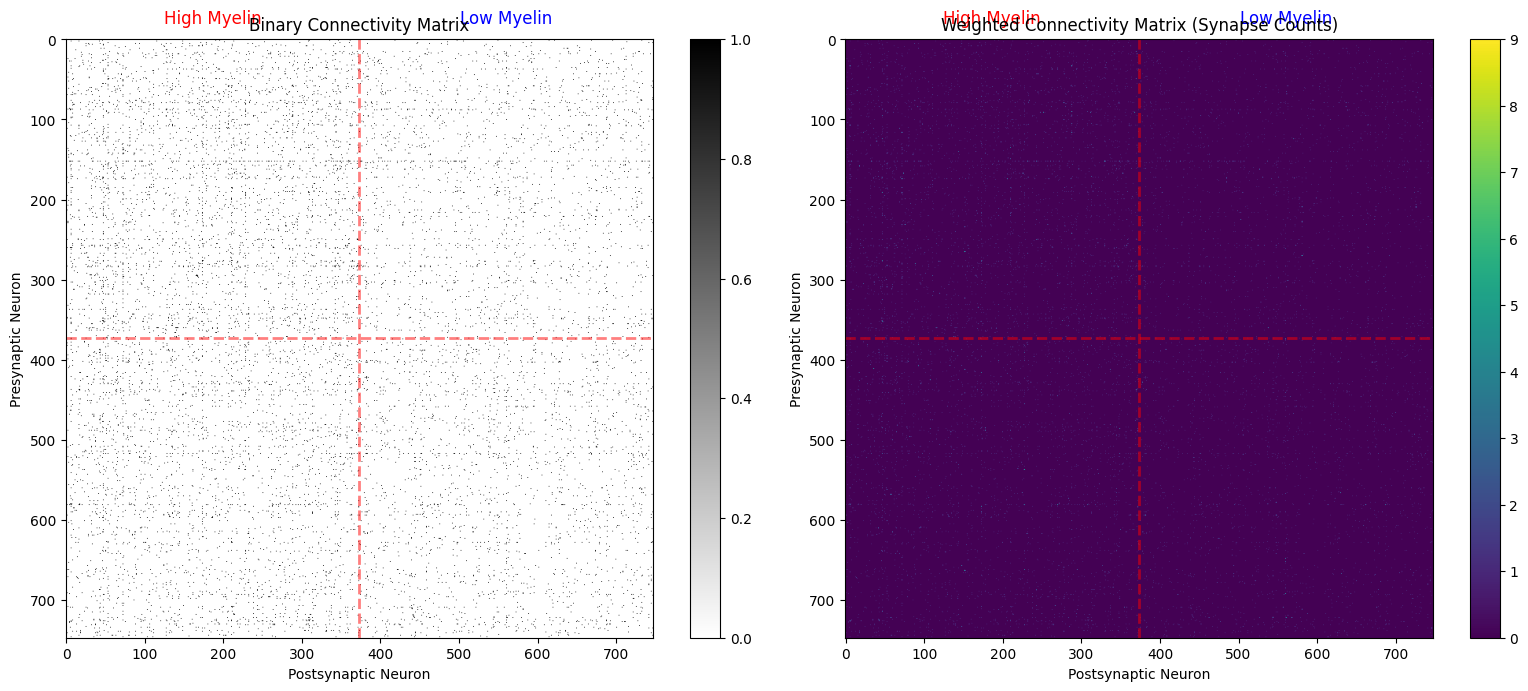

In [53]:
# Visualize connectivity matrices
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Binary adjacency
im1 = axes[0].imshow(adjacency_binary, cmap='binary', aspect='auto')
axes[0].set_title('Binary Connectivity Matrix')
axes[0].set_xlabel('Postsynaptic Neuron')
axes[0].set_ylabel('Presynaptic Neuron')

# Add group boundaries
boundary = high_myelin_indices[-1]
axes[0].axhline(boundary, color='red', linestyle='--', linewidth=2, alpha=0.5)
axes[0].axvline(boundary, color='red', linestyle='--', linewidth=2, alpha=0.5)
axes[0].text(boundary/2, -20, 'High Myelin', ha='center', fontsize=12, color='red')
axes[0].text(boundary + (n_neurons-boundary)/2, -20, 'Low Myelin', ha='center', fontsize=12, color='blue')

plt.colorbar(im1, ax=axes[0])

# Weighted adjacency
im2 = axes[1].imshow(adjacency_weighted, cmap='viridis', aspect='auto')
axes[1].set_title('Weighted Connectivity Matrix (Synapse Counts)')
axes[1].set_xlabel('Postsynaptic Neuron')
axes[1].set_ylabel('Presynaptic Neuron')

# Add group boundaries
axes[1].axhline(boundary, color='red', linestyle='--', linewidth=2, alpha=0.5)
axes[1].axvline(boundary, color='red', linestyle='--', linewidth=2, alpha=0.5)
axes[1].text(boundary/2, -20, 'High Myelin', ha='center', fontsize=12, color='red')
axes[1].text(boundary + (n_neurons-boundary)/2, -20, 'Low Myelin', ha='center', fontsize=12, color='blue')

plt.colorbar(im2, ax=axes[1])

plt.tight_layout()
plt.show()

## Reciprocal Connectivity Analysis

Total connections: 10231.0
Total reciprocal connections: 528
Reciprocal connection rate: 5.16%


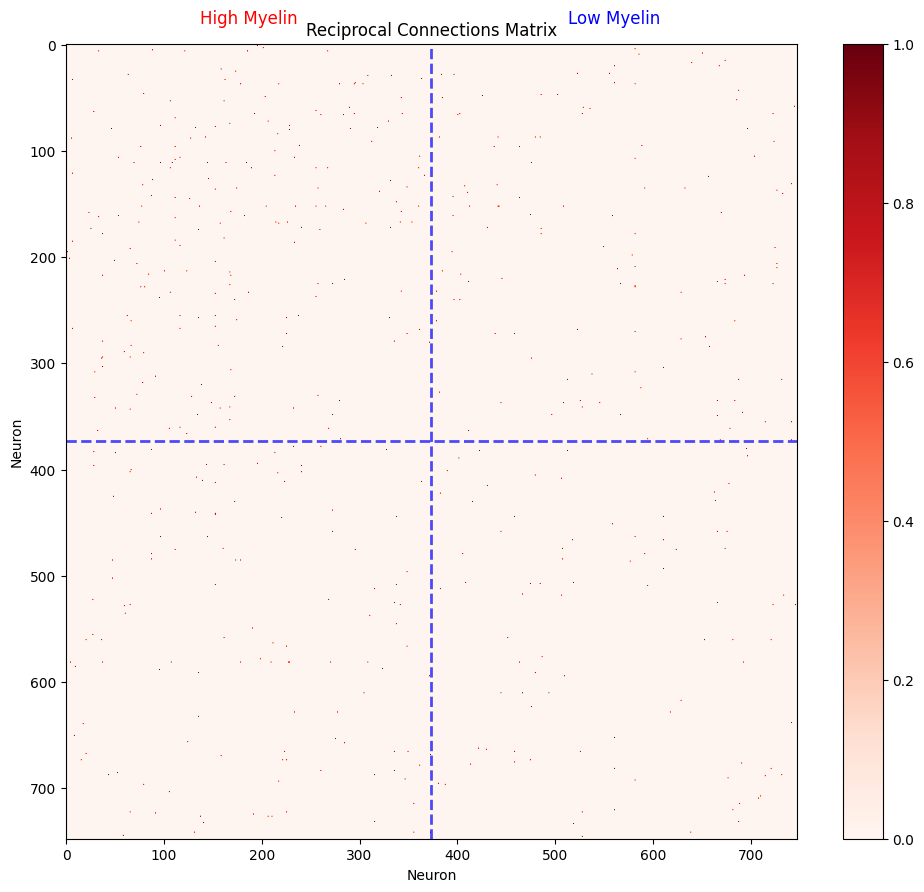

In [54]:
# Compute reciprocal connectivity matrix
reciprocal_matrix = np.logical_and(adjacency_binary, adjacency_binary.T).astype(int)

print(f"Total connections: {np.sum(adjacency_binary)}")
print(f"Total reciprocal connections: {np.sum(reciprocal_matrix)}")
print(f"Reciprocal connection rate: {np.sum(reciprocal_matrix) / np.sum(adjacency_binary) * 100:.2f}%")

# Visualize reciprocal matrix
fig, ax = plt.subplots(figsize=(10, 9))
im = ax.imshow(reciprocal_matrix, cmap='Reds', aspect='auto')
ax.set_title('Reciprocal Connections Matrix')
ax.set_xlabel('Neuron')
ax.set_ylabel('Neuron')

# Add group boundaries
boundary = high_myelin_indices[-1]
ax.axhline(boundary, color='blue', linestyle='--', linewidth=2, alpha=0.7)
ax.axvline(boundary, color='blue', linestyle='--', linewidth=2, alpha=0.7)
ax.text(boundary/2, -20, 'High Myelin', ha='center', fontsize=12, color='red')
ax.text(boundary + (n_neurons-boundary)/2, -20, 'Low Myelin', ha='center', fontsize=12, color='blue')

plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

In [55]:
def get_block_sums(matrix, group1, group2):
    """Get sum of connections in block(s) between two groups"""
    start1, end1 = group_indices[group1]
    start2, end2 = group_indices[group2]
    
    if group1 == group2:
        # Within same group - just one block
        return np.sum(matrix[start1:end1, start2:end2])
    else:
        # Between different groups - sum both directions
        block1 = np.sum(matrix[start1:end1, start2:end2])  # group1 -> group2
        block2 = np.sum(matrix[start2:end2, start1:end1])  # group2 -> group1
        return block1 + block2

def get_connection_strengths(group1, group2):
    """
    Get reciprocal and non-reciprocal connection strengths between two groups.
    Returns: (recip_mean, recip_std, non_recip_mean, non_recip_std, n_recip, n_non_recip)
    """
    start1, end1 = group_indices[group1]
    start2, end2 = group_indices[group2]
    
    # Analyze group1 -> group2 direction
    adj_block = adjacency_weighted[start1:end1, start2:end2]
    recip_block = reciprocal_matrix[start1:end1, start2:end2]
    
    # Get reciprocal connection strengths
    recip_mask = (recip_block == 1) & (adj_block > 0)
    recip_strengths = adj_block[recip_mask]
    
    # Get non-reciprocal connection strengths
    non_recip_mask = (recip_block == 0) & (adj_block > 0)
    non_recip_strengths = adj_block[non_recip_mask]
    
    # Calculate statistics
    recip_mean = np.mean(recip_strengths) if len(recip_strengths) > 0 else 0
    recip_std = np.std(recip_strengths) if len(recip_strengths) > 0 else 0
    
    non_recip_mean = np.mean(non_recip_strengths) if len(non_recip_strengths) > 0 else 0
    non_recip_std = np.std(non_recip_strengths) if len(non_recip_strengths) > 0 else 0
    
    return recip_mean, recip_std, non_recip_mean, non_recip_std, len(recip_strengths), len(non_recip_strengths)

print("Helper functions defined.")

Helper functions defined.


In [56]:
# Analyze reciprocal connection counts
recip_counts = pd.DataFrame(index=myelin_groups, columns=myelin_groups, dtype=int)
total_counts = pd.DataFrame(index=myelin_groups, columns=myelin_groups, dtype=int)
recip_ratios = pd.DataFrame(index=myelin_groups, columns=myelin_groups, dtype=float)

for g1 in myelin_groups:
    for g2 in myelin_groups:
        recip_count = get_block_sums(reciprocal_matrix, g1, g2)
        total_count = get_block_sums(adjacency_binary, g1, g2)
        
        recip_counts.loc[g1, g2] = recip_count
        total_counts.loc[g1, g2] = total_count
        recip_ratios.loc[g1, g2] = recip_count / total_count if total_count > 0 else 0

print("\n=== Reciprocal Connection Counts ===")
print(recip_counts)
print("\n=== Total Connection Counts ===")
print(total_counts)
print("\n=== Reciprocal Connection Ratios ===")
print(recip_ratios.round(3))


=== Reciprocal Connection Counts ===
             high_myelin  low_myelin
high_myelin        200.0       242.0
low_myelin         242.0        86.0

=== Total Connection Counts ===
             high_myelin  low_myelin
high_myelin       3357.0      4772.0
low_myelin        4772.0      2102.0

=== Reciprocal Connection Ratios ===
             high_myelin  low_myelin
high_myelin        0.060       0.051
low_myelin         0.051       0.041


## Connection Strength Analysis

In [57]:
# Analyze connection strengths
recip_means = pd.DataFrame(index=myelin_groups, columns=myelin_groups, dtype=float)
recip_stds = pd.DataFrame(index=myelin_groups, columns=myelin_groups, dtype=float)
non_recip_means = pd.DataFrame(index=myelin_groups, columns=myelin_groups, dtype=float)
non_recip_stds = pd.DataFrame(index=myelin_groups, columns=myelin_groups, dtype=float)
strength_table = pd.DataFrame(index=myelin_groups, columns=myelin_groups)

print("Calculating connection strengths...\n")

for g1 in myelin_groups:
    for g2 in myelin_groups:
        recip_mean, recip_std, non_recip_mean, non_recip_std, n_recip, n_non_recip = get_connection_strengths(g1, g2)
        
        # Store values
        recip_means.loc[g1, g2] = recip_mean
        recip_stds.loc[g1, g2] = recip_std
        non_recip_means.loc[g1, g2] = non_recip_mean
        non_recip_stds.loc[g1, g2] = non_recip_std
        
        # Format as "recip_mean ± recip_std / non_recip_mean ± non_recip_std"
        recip_str = f"{recip_mean:.1f} ± {recip_std:.1f}" if n_recip > 0 else "0 ± 0"
        non_recip_str = f"{non_recip_mean:.1f} ± {non_recip_std:.1f}" if n_non_recip > 0 else "0 ± 0"
        
        strength_table.loc[g1, g2] = f"{recip_str} / {non_recip_str}"
        
        print(f"{g1} -> {g2}: Recip={recip_mean:.2f}±{recip_std:.2f} (n={n_recip}), Non-recip={non_recip_mean:.2f}±{non_recip_std:.2f} (n={n_non_recip})")

print("\n=== Connection Strength Summary ===")
print("Format: 'reciprocal_mean ± std / non_reciprocal_mean ± std'")
print(strength_table)

Calculating connection strengths...

high_myelin -> high_myelin: Recip=1.38±1.01 (n=200), Non-recip=1.18±0.56 (n=3157)
high_myelin -> low_myelin: Recip=1.34±0.91 (n=121), Non-recip=1.10±0.36 (n=1840)
low_myelin -> high_myelin: Recip=1.37±0.78 (n=121), Non-recip=1.16±0.51 (n=2690)
low_myelin -> low_myelin: Recip=1.19±0.44 (n=86), Non-recip=1.11±0.41 (n=2016)

=== Connection Strength Summary ===
Format: 'reciprocal_mean ± std / non_reciprocal_mean ± std'
                       high_myelin             low_myelin
high_myelin  1.4 ± 1.0 / 1.2 ± 0.6  1.3 ± 0.9 / 1.1 ± 0.4
low_myelin   1.4 ± 0.8 / 1.2 ± 0.5  1.2 ± 0.4 / 1.1 ± 0.4


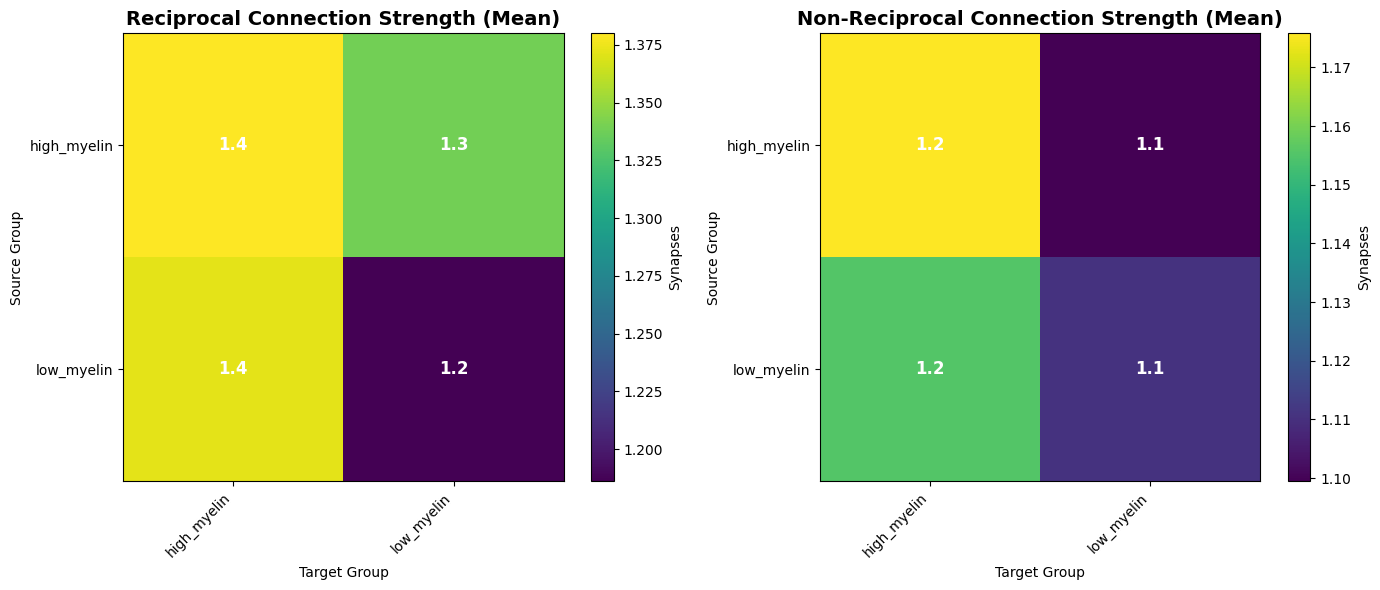

In [58]:
# Visualize connection strengths
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 1. Reciprocal connections mean heatmap
im1 = axes[0].imshow(recip_means.astype(float), cmap='viridis', aspect='auto')
axes[0].set_title('Reciprocal Connection Strength (Mean)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Target Group')
axes[0].set_ylabel('Source Group')
axes[0].set_xticks(range(len(myelin_groups)))
axes[0].set_yticks(range(len(myelin_groups)))
axes[0].set_xticklabels(myelin_groups, rotation=45, ha='right')
axes[0].set_yticklabels(myelin_groups)

# Add text annotations
for i in range(len(myelin_groups)):
    for j in range(len(myelin_groups)):
        value = recip_means.iloc[i, j]
        if not np.isnan(value):
            axes[0].text(j, i, f'{value:.1f}', ha='center', va='center',
                        color='white' if value > recip_means.max().max()/2 else 'black',
                        fontsize=12, fontweight='bold')

plt.colorbar(im1, ax=axes[0], label='Synapses')

# 2. Non-reciprocal connections mean heatmap
im2 = axes[1].imshow(non_recip_means.astype(float), cmap='viridis', aspect='auto')
axes[1].set_title('Non-Reciprocal Connection Strength (Mean)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Target Group')
axes[1].set_ylabel('Source Group')
axes[1].set_xticks(range(len(myelin_groups)))
axes[1].set_yticks(range(len(myelin_groups)))
axes[1].set_xticklabels(myelin_groups, rotation=45, ha='right')
axes[1].set_yticklabels(myelin_groups)

# Add text annotations
for i in range(len(myelin_groups)):
    for j in range(len(myelin_groups)):
        value = non_recip_means.iloc[i, j]
        if not np.isnan(value):
            axes[1].text(j, i, f'{value:.1f}', ha='center', va='center',
                        color='white' if value > non_recip_means.max().max()/2 else 'black',
                        fontsize=12, fontweight='bold')

plt.colorbar(im2, ax=axes[1], label='Synapses')

plt.tight_layout()
plt.show()


=== Ratio of Reciprocal to Non-Reciprocal Connection Strength ===
             high_myelin  low_myelin
high_myelin        1.174       1.218
low_myelin         1.187       1.068


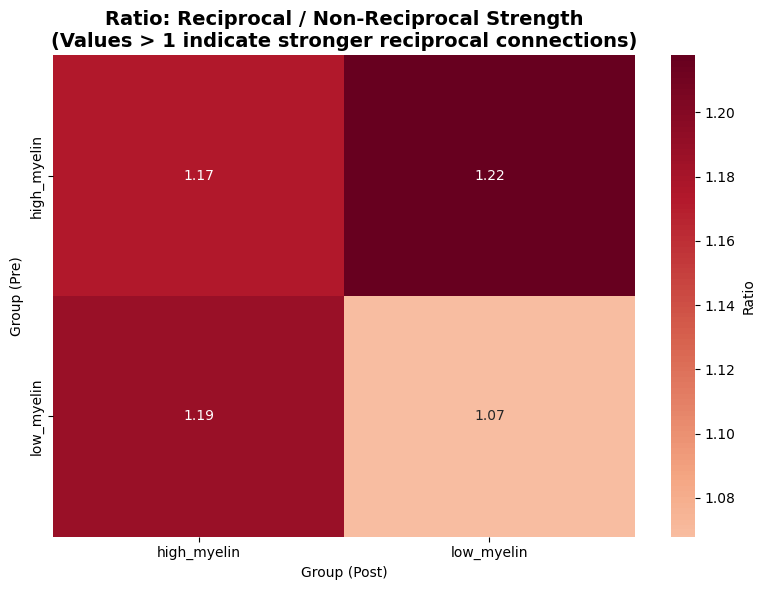

In [59]:
# Compute ratio of reciprocal to non-reciprocal strength
ratio_table = pd.DataFrame(index=myelin_groups, columns=myelin_groups, dtype=float)

for g1 in myelin_groups:
    for g2 in myelin_groups:
        recip_mean = recip_means.loc[g1, g2]
        non_recip_mean = non_recip_means.loc[g1, g2]
        
        if non_recip_mean > 0:
            ratio_table.loc[g1, g2] = recip_mean / non_recip_mean
        else:
            ratio_table.loc[g1, g2] = np.nan

print("\n=== Ratio of Reciprocal to Non-Reciprocal Connection Strength ===")
print(ratio_table.round(3))

# Plot ratio
plt.figure(figsize=(8, 6))
sns.heatmap(ratio_table, annot=True, fmt='.2f', cmap='RdBu_r', center=1, cbar_kws={'label': 'Ratio'})
plt.title('Ratio: Reciprocal / Non-Reciprocal Strength\n(Values > 1 indicate stronger reciprocal connections)', 
          fontsize=14, fontweight='bold')
plt.ylabel('Group (Pre)')
plt.xlabel('Group (Post)')
plt.tight_layout()
plt.show()

## Statistical Testing

In [60]:
# Statistical comparisons using Mann-Whitney U tests
print("\n=== Statistical Comparisons (Mann-Whitney U Tests) ===")
print("Testing if reciprocal connections are significantly stronger than non-reciprocal")
print("=" * 80)

significance_table = pd.DataFrame(index=myelin_groups, columns=myelin_groups)

for g1 in myelin_groups:
    for g2 in myelin_groups:
        start1, end1 = group_indices[g1]
        start2, end2 = group_indices[g2]
        
        if g1 == g2:
            # Within same group
            adj_block = adjacency_weighted[start1:end1, start2:end2]
            recip_block = reciprocal_matrix[start1:end1, start2:end2]
            
            recip_mask = (recip_block == 1) & (adj_block > 0)
            non_recip_mask = (recip_block == 0) & (adj_block > 0)
            
            recip_strengths = adj_block[recip_mask]
            non_recip_strengths = adj_block[non_recip_mask]
        else:
            # Between different groups - combine both directions
            adj_block1 = adjacency_weighted[start1:end1, start2:end2]
            adj_block2 = adjacency_weighted[start2:end2, start1:end1]
            recip_block1 = reciprocal_matrix[start1:end1, start2:end2]
            recip_block2 = reciprocal_matrix[start2:end2, start1:end1]
            
            recip_mask1 = (recip_block1 == 1) & (adj_block1 > 0)
            recip_mask2 = (recip_block2 == 1) & (adj_block2 > 0)
            non_recip_mask1 = (recip_block1 == 0) & (adj_block1 > 0)
            non_recip_mask2 = (recip_block2 == 0) & (adj_block2 > 0)
            
            recip_strengths = np.concatenate([adj_block1[recip_mask1], adj_block2[recip_mask2]])
            non_recip_strengths = np.concatenate([adj_block1[non_recip_mask1], adj_block2[non_recip_mask2]])
        
        if len(recip_strengths) > 5 and len(non_recip_strengths) > 5:
            statistic, p_value = stats.mannwhitneyu(recip_strengths, non_recip_strengths, alternative='two-sided')
            
            if p_value < 0.001:
                sig_level = "***"
            elif p_value < 0.01:
                sig_level = "**"
            elif p_value < 0.05:
                sig_level = "*"
            else:
                sig_level = "ns"
            
            significance_table.loc[g1, g2] = f"p={p_value:.4f} {sig_level}"
            
            recip_median = np.median(recip_strengths)
            non_recip_median = np.median(non_recip_strengths)
            
            print(f"\n{g1} -> {g2}:")
            print(f"  Reciprocal: n={len(recip_strengths)}, median={recip_median:.1f}, mean={np.mean(recip_strengths):.1f}")
            print(f"  Non-reciprocal: n={len(non_recip_strengths)}, median={non_recip_median:.1f}, mean={np.mean(non_recip_strengths):.1f}")
            print(f"  Test: U={statistic:.0f}, p={p_value:.4f} {sig_level}")
        else:
            significance_table.loc[g1, g2] = "insufficient_data"
            print(f"\n{g1} -> {g2}: Insufficient data (recip={len(recip_strengths)}, non_recip={len(non_recip_strengths)})")

print("\n=== Significance Table ===")
print(significance_table)


=== Statistical Comparisons (Mann-Whitney U Tests) ===
Testing if reciprocal connections are significantly stronger than non-reciprocal

high_myelin -> high_myelin:
  Reciprocal: n=200, median=1.0, mean=1.4
  Non-reciprocal: n=3157, median=1.0, mean=1.2
  Test: U=343678, p=0.0003 ***

high_myelin -> low_myelin:
  Reciprocal: n=242, median=1.0, mean=1.4
  Non-reciprocal: n=4530, median=1.0, mean=1.1
  Test: U=615338, p=0.0000 ***

low_myelin -> high_myelin:
  Reciprocal: n=242, median=1.0, mean=1.4
  Non-reciprocal: n=4530, median=1.0, mean=1.1
  Test: U=615338, p=0.0000 ***

low_myelin -> low_myelin:
  Reciprocal: n=86, median=1.0, mean=1.2
  Non-reciprocal: n=2016, median=1.0, mean=1.1
  Test: U=93121, p=0.0194 *

=== Significance Table ===
              high_myelin    low_myelin
high_myelin  p=0.0003 ***  p=0.0000 ***
low_myelin   p=0.0000 ***    p=0.0194 *


## Summary Statistics

SUMMARY: RECIPROCAL CONNECTIVITY IN HIGH VS LOW MYELIN GROUPS

1. Overall Connection Strengths:
   - Mean reciprocal connection strength: 1.32 synapses
   - Mean non-reciprocal connection strength: 1.14 synapses
   - Overall ratio (reciprocal/non-reciprocal): 1.16

2. Reciprocal Connection Rates:
   - high_myelin <-> high_myelin: 6.0% (200.0/3357.0 connections)
   - high_myelin <-> low_myelin: 5.1% (242.0/4772.0 connections)
   - low_myelin <-> high_myelin: 5.1% (242.0/4772.0 connections)
   - low_myelin <-> low_myelin: 4.1% (86.0/2102.0 connections)

3. Group-Specific Findings:
   - High myelin neurons (within group):
     * Reciprocal connection rate: 6.0%
     * Strength ratio (recip/non-recip): 1.17
   - Low myelin neurons (within group):
     * Reciprocal connection rate: 4.1%
     * Strength ratio (recip/non-recip): 1.07
   - Between high and low myelin groups:
     * Reciprocal connection rate: 5.1%
     * Strength ratio (recip/non-recip): 1.22

4. Key Findings:
   - High myelin

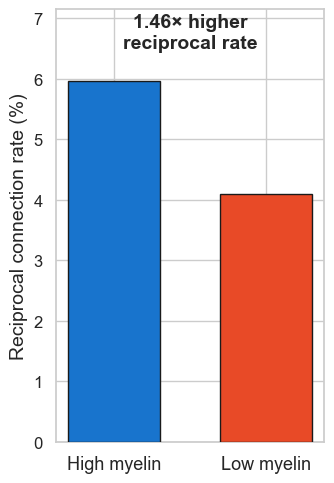

In [ ]:
print("="*80)
print("SUMMARY: RECIPROCAL CONNECTIVITY IN HIGH VS LOW MYELIN GROUPS")
print("="*80)

# Overall statistics
overall_recip_mean = np.nanmean(recip_means.values)
overall_non_recip_mean = np.nanmean(non_recip_means.values)
overall_ratio = overall_recip_mean / overall_non_recip_mean if overall_non_recip_mean > 0 else np.nan

print(f"\n1. Overall Connection Strengths:")
print(f"   - Mean reciprocal connection strength: {overall_recip_mean:.2f} synapses")
print(f"   - Mean non-reciprocal connection strength: {overall_non_recip_mean:.2f} synapses")
print(f"   - Overall ratio (reciprocal/non-reciprocal): {overall_ratio:.2f}")

# Reciprocal connection rates
print(f"\n2. Reciprocal Connection Rates:")
for g1 in myelin_groups:
    for g2 in myelin_groups:
        ratio = recip_ratios.loc[g1, g2]
        total = total_counts.loc[g1, g2]
        recip = recip_counts.loc[g1, g2]
        print(f"   - {g1} <-> {g2}: {ratio:.1%} ({recip}/{total} connections)")

# Group comparisons
print(f"\n3. Group-Specific Findings:")

# High myelin within-group
high_high_ratio = recip_ratios.loc['high_myelin', 'high_myelin']
high_high_strength_ratio = ratio_table.loc['high_myelin', 'high_myelin']
print(f"   - High myelin neurons (within group):")
print(f"     * Reciprocal connection rate: {high_high_ratio:.1%}")
print(f"     * Strength ratio (recip/non-recip): {high_high_strength_ratio:.2f}")

# Low myelin within-group  
low_low_ratio = recip_ratios.loc['low_myelin', 'low_myelin']
low_low_strength_ratio = ratio_table.loc['low_myelin', 'low_myelin']
print(f"   - Low myelin neurons (within group):")
print(f"     * Reciprocal connection rate: {low_low_ratio:.1%}")
print(f"     * Strength ratio (recip/non-recip): {low_low_strength_ratio:.2f}")

# Between groups
high_low_ratio = recip_ratios.loc['high_myelin', 'low_myelin']
high_low_strength_ratio = ratio_table.loc['high_myelin', 'low_myelin']
print(f"   - Between high and low myelin groups:")
print(f"     * Reciprocal connection rate: {high_low_ratio:.1%}")
print(f"     * Strength ratio (recip/non-recip): {high_low_strength_ratio:.2f}")

# Key findings
print(f"\n4. Key Findings:")

# Compute the reciprocal rate ratio for text and annotate for plotting
recip_rate_ratio = high_high_ratio / low_low_ratio if low_low_ratio > 0 else float('nan')

if high_high_ratio > low_low_ratio:
    print(f"   - High myelin neurons have {recip_rate_ratio:.2f}x higher reciprocal connection rate than low myelin neurons")
else:
    print(f"   - Low myelin neurons have {(low_low_ratio/high_high_ratio):.2f}x higher reciprocal connection rate than high myelin neurons")

if high_high_strength_ratio > low_low_strength_ratio:
    print(f"   - High myelin neurons have {high_high_strength_ratio/low_low_strength_ratio:.2f}x stronger reciprocal connections (relative to non-reciprocal)")
else:
    print(f"   - Low myelin neurons have {low_low_strength_ratio/high_high_strength_ratio:.2f}x stronger reciprocal connections (relative to non-reciprocal)")

# Count significant differences
sig_count = sum([1 for g1 in myelin_groups for g2 in myelin_groups 
                if significance_table.loc[g1, g2] not in ['insufficient_data', None] 
                and 'ns' not in str(significance_table.loc[g1, g2])])
total_comparisons = len(myelin_groups) * len(myelin_groups)

print(f"\n5. Statistical Significance:")
print(f"   - {sig_count}/{total_comparisons} group comparisons show significant differences (p < 0.05)")
print(f"   - See significance table above for details")

print("\n" + "="*80)

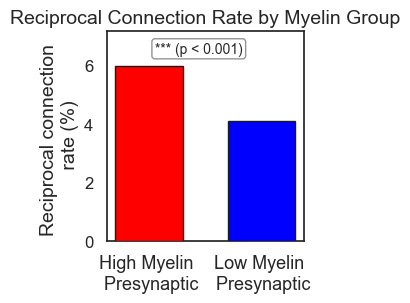

In [109]:
# ==== PUBLICATION-QUALITY FIGURE: Reciprocal connection rate, high vs. low myelin ====
import matplotlib.pyplot as plt
import seaborn as sns

# Data for plot
rates = [high_high_ratio, low_low_ratio]
groups = ['High Myelin \n Presynaptic', 'Low Myelin \n Presynaptic']

# Shrink figure while keeping label sizes
fig, ax = plt.subplots(figsize=(3.0, 3.2))  # reduced from (3.5, 5)

bar_colors = [(1, 0, 0, 0.45), (0, 0, 1, 0.45)]  # matplotlib RGBA for 'red', 'blue', with transparency

sns.set(style="white")
bars = ax.bar(
    groups, 
    [r * 100 for r in rates], 
    color=bar_colors, 
    width=0.6, 
    edgecolor='k', 
    zorder=10,
    alpha=1  # alpha handled in RGBA tuples above
)

# Add annotation for ratio
y_max = max(rates) * 100

sig = "*** (p < 0.001)"

ax.annotate(f'{sig}', 
        xy=(0.69, 0.95), xycoords='axes fraction',
        ha='right', va='top', fontsize=10,
        bbox=dict(facecolor='white', edgecolor='gray', boxstyle='round,pad=0.22', alpha=0.84))

# Formatting
ax.set_ylabel("Reciprocal connection \n rate (%)", fontsize=14)
ax.set_xlabel("")
ax.set_ylim(0, y_max * 1.2)
ax.set_xticks(range(len(groups)))
ax.set_xticklabels(groups, fontsize=13)
ax.tick_params(axis='y', labelsize=12)
ax.set_title('Reciprocal Connection Rate by Myelin Group', fontsize=14)
plt.tight_layout()

# plt.savefig("recip_connection_rate_high_vs_low_myelin.svg", bbox_inches='tight')

plt.show()

In [23]:
# Load myelin data
myelin_df = pd.read_csv('/Users/artliang/Documents/Myelin Plasticity/Myelin_Extract/myelin_info_df (4).csv')
print(f"Loaded {len(myelin_df)} neurons total")

# Filter to only excitatory neurons (exclude BC, MC, BPC)
inhibitory_types = ['BC', 'MC', 'BPC']
excitatory_df = myelin_df[~myelin_df['cell_type'].isin(inhibitory_types)].copy()

print(f"\nAfter filtering to excitatory neurons: {len(excitatory_df)} neurons")
print(f"\nExcitatory cell types:")
print(excitatory_df['cell_type'].value_counts())

print(f"\nMyelin length statistics (excitatory only):")
print(excitatory_df['total_myelin_length'].describe())

Loaded 804 neurons total

After filtering to excitatory neurons: 748 neurons

Excitatory cell types:
cell_type
23P      252
4P       219
5P-IT    170
6P-IT     67
5P-ET     25
6P-CT     12
5P-NP      3
Name: count, dtype: int64

Myelin length statistics (excitatory only):
count     748.000000
mean      261.381618
std       341.327541
min         0.000000
25%         0.505000
50%       145.615000
75%       402.415000
max      2275.130000
Name: total_myelin_length, dtype: float64


In [24]:
# Create high and low myelin groups using median split
median_myelin = excitatory_df['total_myelin_length'].median()
print(f"Median myelin length (excitatory neurons): {median_myelin:.2f} μm")

# Assign groups
excitatory_df['myelin_group'] = excitatory_df['total_myelin_length'].apply(
    lambda x: 'high_myelin' if x > median_myelin else 'low_myelin'
)

# Display group statistics
print(f"\nGroup sizes:")
print(excitatory_df['myelin_group'].value_counts())

high_myelin_neurons = set(excitatory_df[excitatory_df['myelin_group'] == 'high_myelin']['pt_root_id'])
low_myelin_neurons = set(excitatory_df[excitatory_df['myelin_group'] == 'low_myelin']['pt_root_id'])

print(f"\nHigh myelin group:")
print(f"  - Count: {len(high_myelin_neurons)}")
print(f"  - Mean myelin: {excitatory_df[excitatory_df['myelin_group']=='high_myelin']['total_myelin_length'].mean():.2f} μm")
print(f"  - Std: {excitatory_df[excitatory_df['myelin_group']=='high_myelin']['total_myelin_length'].std():.2f} μm")

print(f"\nLow myelin group:")
print(f"  - Count: {len(low_myelin_neurons)}")
print(f"  - Mean myelin: {excitatory_df[excitatory_df['myelin_group']=='low_myelin']['total_myelin_length'].mean():.2f} μm")
print(f"  - Std: {excitatory_df[excitatory_df['myelin_group']=='low_myelin']['total_myelin_length'].std():.2f} μm")

Median myelin length (excitatory neurons): 145.62 μm

Group sizes:
myelin_group
high_myelin    374
low_myelin     374
Name: count, dtype: int64

High myelin group:
  - Count: 374
  - Mean myelin: 493.82 μm
  - Std: 350.79 μm

Low myelin group:
  - Count: 374
  - Mean myelin: 28.94 μm
  - Std: 43.87 μm


In [25]:
# Assign myelin groups to pre and post neurons
syn_df['pre_myelin_group'] = syn_df['pre_pt_root_id'].apply(
    lambda x: 'high_myelin' if x in high_myelin_neurons else ('low_myelin' if x in low_myelin_neurons else 'unknown')
)

syn_df['post_myelin_group'] = syn_df['post_pt_root_id'].apply(
    lambda x: 'high_myelin' if x in high_myelin_neurons else ('low_myelin' if x in low_myelin_neurons else 'unknown')
)

# Verify no unknowns
print(f"Pre myelin group distribution:")
print(syn_df['pre_myelin_group'].value_counts())
print(f"\nPost myelin group distribution:")
print(syn_df['post_myelin_group'].value_counts())

Pre myelin group distribution:
pre_myelin_group
unknown        13016
high_myelin     8246
low_myelin      7459
Name: count, dtype: int64

Post myelin group distribution:
post_myelin_group
high_myelin    14493
low_myelin      9397
unknown         4831
Name: count, dtype: int64


In [26]:
excitatory_ids = excitatory_df['pt_root_id'].tolist()


In [27]:
# For each presynaptic neuron, compute the number and ratio of synapses onto high vs low myelin targets
connection_stats = []

for pre_id in excitatory_ids:
    # Get all synapses from this presynaptic neuron
    pre_synapses = syn_df[syn_df['pre_pt_root_id'] == pre_id]
    
    if len(pre_synapses) == 0:
        continue
    
    # Count synapses onto high vs low myelin targets
    n_onto_high = len(pre_synapses[pre_synapses['post_myelin_group'] == 'high_myelin'])
    n_onto_low = len(pre_synapses[pre_synapses['post_myelin_group'] == 'low_myelin'])
    n_total = n_onto_high + n_onto_low
    
    # Get presynaptic neuron's myelin group
    pre_group = 'high_myelin' if pre_id in high_myelin_neurons else 'low_myelin'
    
    # Get myelin length
    myelin_length = excitatory_df[excitatory_df['pt_root_id'] == pre_id]['total_myelin_length'].values[0]
    
    # Compute ratio (fraction of synapses onto high myelin targets)
    if n_total > 0:
        fraction_onto_high = n_onto_high / n_total
    else:
        fraction_onto_high = np.nan
    
    connection_stats.append({
        'pre_neuron_id': pre_id,
        'pre_myelin_group': pre_group,
        'pre_myelin_length': myelin_length,
        'n_synapses_onto_high': n_onto_high,
        'n_synapses_onto_low': n_onto_low,
        'n_synapses_total': n_total,
        'fraction_onto_high_myelin': fraction_onto_high
    })

stats_df = pd.DataFrame(connection_stats)

# Remove neurons with no outgoing synapses
stats_df = stats_df[stats_df['n_synapses_total'] > 0].copy()

print(f"\nAnalyzed {len(stats_df)} neurons with outgoing connections")
print(f"\nSample of data:")
print(stats_df.head(10))


Analyzed 724 neurons with outgoing connections

Sample of data:
         pre_neuron_id pre_myelin_group  pre_myelin_length  \
1   864691136041000190       low_myelin               0.00   
2   864691135938604804      high_myelin             279.49   
3   864691136578982164       low_myelin               0.00   
4   864691135209715577       low_myelin               0.00   
5   864691134949263100       low_myelin             130.05   
6   864691135700409211      high_myelin             266.10   
7   864691136313301565      high_myelin             490.47   
8   864691135417236410      high_myelin             712.50   
9   864691135101521952       low_myelin               0.00   
10  864691135562147041       low_myelin              64.30   

    n_synapses_onto_high  n_synapses_onto_low  n_synapses_total  \
1                      1                   11                12   
2                     26                   12                38   
3                      1                    1      

In [28]:
# Summary statistics by presynaptic myelin group
print("="*80)
print("SUMMARY: TARGET PREFERENCES BY PRESYNAPTIC MYELIN GROUP")
print("="*80)

for group in ['high_myelin', 'low_myelin']:
    group_data = stats_df[stats_df['pre_myelin_group'] == group]
    
    mean_frac = group_data['fraction_onto_high_myelin'].mean()
    median_frac = group_data['fraction_onto_high_myelin'].median()
    std_frac = group_data['fraction_onto_high_myelin'].std()
    
    total_synapses_onto_high = group_data['n_synapses_onto_high'].sum()
    total_synapses_onto_low = group_data['n_synapses_onto_low'].sum()
    total_synapses = total_synapses_onto_high + total_synapses_onto_low
    overall_frac = total_synapses_onto_high / total_synapses if total_synapses > 0 else 0
    
    print(f"\n{group.upper()} presynaptic neurons (n={len(group_data)}):")
    print(f"  Fraction of synapses onto high myelin targets:")
    print(f"    - Mean: {mean_frac:.3f} ± {std_frac:.3f}")
    print(f"    - Median: {median_frac:.3f}")
    print(f"    - Range: [{group_data['fraction_onto_high_myelin'].min():.3f}, {group_data['fraction_onto_high_myelin'].max():.3f}]")
    print(f"  Total synapses:")
    print(f"    - Onto high myelin: {total_synapses_onto_high:,} ({overall_frac:.1%})")
    print(f"    - Onto low myelin: {total_synapses_onto_low:,} ({1-overall_frac:.1%})")
    print(f"    - Total: {total_synapses:,}")

# Expected value (null hypothesis: random connectivity)
expected_frac = len(high_myelin_neurons) / len(excitatory_ids)
print(f"\n\nEXPECTED (if random): {expected_frac:.3f}")
print(f"  (Based on {len(high_myelin_neurons)}/{len(excitatory_ids)} neurons being high myelin)")

SUMMARY: TARGET PREFERENCES BY PRESYNAPTIC MYELIN GROUP

HIGH_MYELIN presynaptic neurons (n=364):
  Fraction of synapses onto high myelin targets:
    - Mean: 0.672 ± 0.210
    - Median: 0.667
    - Range: [0.000, 1.000]
  Total synapses:
    - Onto high myelin: 3,988 (64.6%)
    - Onto low myelin: 2,185 (35.4%)
    - Total: 6,173

LOW_MYELIN presynaptic neurons (n=360):
  Fraction of synapses onto high myelin targets:
    - Mean: 0.584 ± 0.219
    - Median: 0.588
    - Range: [0.000, 1.000]
  Total synapses:
    - Onto high myelin: 3,274 (58.3%)
    - Onto low myelin: 2,341 (41.7%)
    - Total: 5,615


EXPECTED (if random): 0.500
  (Based on 374/748 neurons being high myelin)


In [29]:
# Statistical test: Do high myelin neurons target high myelin neurons more than low myelin neurons do?
high_pre_fractions = stats_df[stats_df['pre_myelin_group'] == 'high_myelin']['fraction_onto_high_myelin']
low_pre_fractions = stats_df[stats_df['pre_myelin_group'] == 'low_myelin']['fraction_onto_high_myelin']

# Mann-Whitney U test
statistic, p_value = stats.mannwhitneyu(high_pre_fractions, low_pre_fractions, alternative='two-sided')

print("\n" + "="*80)
print("STATISTICAL TEST: Mann-Whitney U Test")
print("="*80)
print(f"\nNull hypothesis: High and low myelin neurons have similar target preferences")
print(f"\nResults:")
print(f"  U-statistic: {statistic:.2f}")
print(f"  p-value: {p_value:.6f}")

if p_value < 0.001:
    sig = "*** (p < 0.001)"
elif p_value < 0.01:
    sig = "** (p < 0.01)"
elif p_value < 0.05:
    sig = "* (p < 0.05)"
else:
    sig = "ns (not significant)"

print(f"  Significance: {sig}")

high_mean = high_pre_fractions.mean()
low_mean = low_pre_fractions.mean()

if p_value < 0.05:
    if high_mean > low_mean:
        print(f"\nConclusion: High myelin neurons preferentially target other high myelin neurons.")
        print(f"  Effect size: {high_mean/low_mean:.2f}x")
    else:
        print(f"\nConclusion: High myelin neurons preferentially target low myelin neurons.")
        print(f"  Effect size: {low_mean/high_mean:.2f}x")
else:
    print(f"\nConclusion: No significant difference in target preferences between groups.")


STATISTICAL TEST: Mann-Whitney U Test

Null hypothesis: High and low myelin neurons have similar target preferences

Results:
  U-statistic: 82180.00
  p-value: 0.000000
  Significance: *** (p < 0.001)

Conclusion: High myelin neurons preferentially target other high myelin neurons.
  Effect size: 1.15x


In [30]:
# Test each group against null hypothesis (expected fraction)
print("\n" + "="*80)
print("ONE-SAMPLE TESTS: Comparison to Random Expectation")
print("="*80)
print(f"\nExpected fraction (null): {expected_frac:.3f}")

for group in ['high_myelin', 'low_myelin']:
    group_fractions = stats_df[stats_df['pre_myelin_group'] == group]['fraction_onto_high_myelin']
    
    # Wilcoxon signed-rank test (one-sample)
    # Testing if median differs from expected_frac
    differences = group_fractions - expected_frac
    statistic_w, p_value_w = stats.wilcoxon(differences, alternative='two-sided')
    
    print(f"\n{group.upper()}:")
    print(f"  Observed mean: {group_fractions.mean():.3f}")
    print(f"  Observed median: {group_fractions.median():.3f}")
    print(f"  Wilcoxon test: W={statistic_w:.2f}, p={p_value_w:.6f}")
    
    if p_value_w < 0.05:
        if group_fractions.median() > expected_frac:
            print(f"  Result: Significantly PREFERS high myelin targets (p < 0.05)")
        else:
            print(f"  Result: Significantly AVOIDS high myelin targets (p < 0.05)")
    else:
        print(f"  Result: No significant preference (consistent with random connectivity)")


ONE-SAMPLE TESTS: Comparison to Random Expectation

Expected fraction (null): 0.500

HIGH_MYELIN:
  Observed mean: 0.672
  Observed median: 0.667
  Wilcoxon test: W=6281.00, p=0.000000
  Result: Significantly PREFERS high myelin targets (p < 0.05)

LOW_MYELIN:
  Observed mean: 0.584
  Observed median: 0.588
  Wilcoxon test: W=14008.00, p=0.000000
  Result: Significantly PREFERS high myelin targets (p < 0.05)


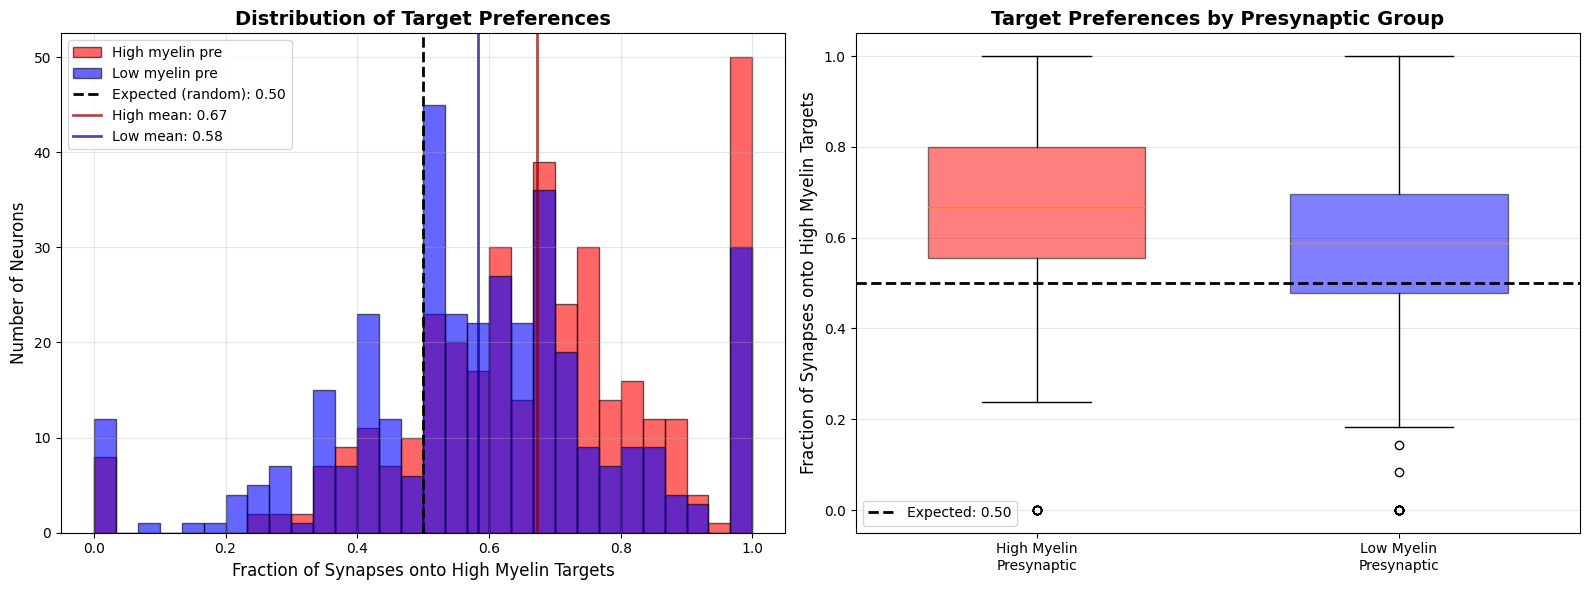

In [31]:
# Plot distributions of target preferences
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Histograms
ax1 = axes[0]
ax1.hist(stats_df[stats_df['pre_myelin_group'] == 'high_myelin']['fraction_onto_high_myelin'],
         alpha=0.6, bins=30, label='High myelin pre', color='red', edgecolor='black')
ax1.hist(stats_df[stats_df['pre_myelin_group'] == 'low_myelin']['fraction_onto_high_myelin'],
         alpha=0.6, bins=30, label='Low myelin pre', color='blue', edgecolor='black')
ax1.axvline(expected_frac, color='black', linestyle='--', linewidth=2, label=f'Expected (random): {expected_frac:.2f}')
ax1.axvline(high_pre_fractions.mean(), color='darkred', linestyle='-', linewidth=2, alpha=0.7, label=f'High mean: {high_pre_fractions.mean():.2f}')
ax1.axvline(low_pre_fractions.mean(), color='darkblue', linestyle='-', linewidth=2, alpha=0.7, label=f'Low mean: {low_pre_fractions.mean():.2f}')

ax1.set_xlabel('Fraction of Synapses onto High Myelin Targets', fontsize=12)
ax1.set_ylabel('Number of Neurons', fontsize=12)
ax1.set_title('Distribution of Target Preferences', fontsize=14, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(alpha=0.3)

# Plot 2: Box plots
ax2 = axes[1]
data_to_plot = [
    stats_df[stats_df['pre_myelin_group'] == 'high_myelin']['fraction_onto_high_myelin'],
    stats_df[stats_df['pre_myelin_group'] == 'low_myelin']['fraction_onto_high_myelin']
]

bp = ax2.boxplot(data_to_plot, labels=['High Myelin\nPresynaptic', 'Low Myelin\nPresynaptic'],
                 patch_artist=True, widths=0.6)

# Color the boxes
bp['boxes'][0].set_facecolor('red')
bp['boxes'][0].set_alpha(0.5)
bp['boxes'][1].set_facecolor('blue')
bp['boxes'][1].set_alpha(0.5)

# Add expected line
ax2.axhline(expected_frac, color='black', linestyle='--', linewidth=2, label=f'Expected: {expected_frac:.2f}')

ax2.set_ylabel('Fraction of Synapses onto High Myelin Targets', fontsize=12)
ax2.set_title('Target Preferences by Presynaptic Group', fontsize=14, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

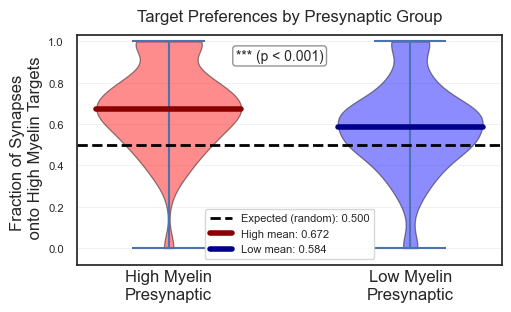

In [106]:
# Violin plot for better distribution visualization with increased font sizes and tighter layout
fig, ax = plt.subplots(figsize=(5, 3))  # Slightly reduced size for tightness

# Prepare data
high_myelin_fractions = stats_df[stats_df['pre_myelin_group'] == 'high_myelin']['fraction_onto_high_myelin']
low_myelin_fractions = stats_df[stats_df['pre_myelin_group'] == 'low_myelin']['fraction_onto_high_myelin']
data = [high_myelin_fractions, low_myelin_fractions]

parts = ax.violinplot(
    data,
    positions=[1, 2],
    widths=0.6
)

# Color the violins
for i, color in enumerate(['red', 'blue']):
    parts['bodies'][i].set_facecolor(color)
    parts['bodies'][i].set_alpha(0.45)
    parts['bodies'][i].set_edgecolor('black')
    parts['bodies'][i].set_linewidth(0.9)

# Expected line
ax.axhline(expected_frac, color='black', linestyle='--', linewidth=2, label=f'Expected (random): {expected_frac:.3f}')

# Mean lines
ax.plot([0.7, 1.3], [high_pre_fractions.mean()]*2, color='darkred', linewidth=4, label=f'High mean: {high_pre_fractions.mean():.3f}')
ax.plot([1.7, 2.3], [low_pre_fractions.mean()]*2, color='darkblue', linewidth=4, label=f'Low mean: {low_pre_fractions.mean():.3f}')

# Axis and label formatting
ax.set_xticks([1, 2])
ax.set_xticklabels(['High Myelin\nPresynaptic', 'Low Myelin\nPresynaptic'], fontsize=12)
ax.set_ylabel('Fraction of Synapses \n onto High Myelin Targets', fontsize=12)
ax.set_title('Target Preferences by Presynaptic Group', fontsize=12, pad=10)
ax.tick_params(axis='y', labelsize=8)
ax.tick_params(axis='x', length=0)
ax.grid(alpha=0.25, axis='y', linestyle='-', linewidth=0.7)
ax.set_ylim(-0.08, 1.03)

# Legend formatting
handles, labels = ax.get_legend_handles_labels()
if not handles:
    # Only add all handles if they were not added before
    from matplotlib.lines import Line2D
    handles = [
        Line2D([0], [0], color='black', linestyle='--', linewidth=2, label=f'Expected (random): {expected_frac:.3f}'),
        Line2D([0], [0], color='darkred', linewidth=4, label=f'High mean: {high_pre_fractions.mean():.3f}'),
        Line2D([0], [0], color='darkblue', linewidth=4, label=f'Low mean: {low_pre_fractions.mean():.3f}')
    ]
ax.legend(handles=handles, fontsize=8, loc='lower center', ncol=1)

# Annotation, made larger and positioned closer to violins
ax.annotate(f'{sig}', 
            xy=(0.58, 0.94), xycoords='axes fraction',
            ha='right', va='top', fontsize=10,
            bbox=dict(facecolor='white', edgecolor='gray', boxstyle='round,pad=0.22', alpha=0.84))

plt.subplots_adjust(left=0.13, right=0.98, top=0.92, bottom=0.155, wspace=0)  # tight layout
plt.show()

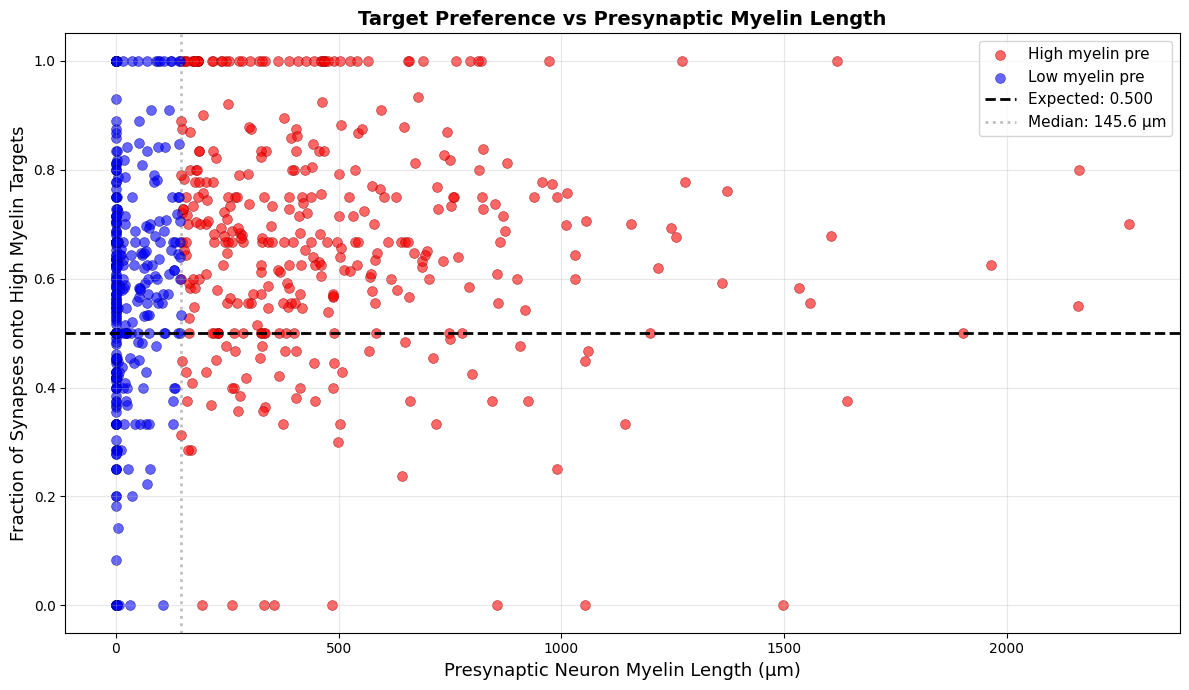

In [ ]:
# Scatter plot: presynaptic myelin length vs target preference
fig, ax = plt.subplots(figsize=(12, 7))

# Plot high myelin neurons
high_data = stats_df[stats_df['pre_myelin_group'] == 'high_myelin']
ax.scatter(high_data['pre_myelin_length'], high_data['fraction_onto_high_myelin'],
           alpha=0.6, s=50, c='red', label='High myelin pre', edgecolors='darkred', linewidth=0.5)

# Plot low myelin neurons
low_data = stats_df[stats_df['pre_myelin_group'] == 'low_myelin']
ax.scatter(low_data['pre_myelin_length'], low_data['fraction_onto_high_myelin'],
           alpha=0.6, s=50, c='blue', label='Low myelin pre', edgecolors='darkblue', linewidth=0.5)

# Add expected line
ax.axhline(expected_frac, color='black', linestyle='--', linewidth=2, label=f'Expected: {expected_frac:.3f}')

# Add vertical line at median
ax.axvline(median_myelin, color='gray', linestyle=':', linewidth=2, alpha=0.5, label=f'Median: {median_myelin:.1f} μm')

ax.set_xlabel('Presynaptic Neuron Myelin Length (μm)', fontsize=13)
ax.set_ylabel('Fraction of Synapses onto High Myelin Targets', fontsize=13)
ax.set_title('Target Preference vs Presynaptic Myelin Length', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(alpha=0.3)
ax.set_ylim(-0.05, 1.05)

plt.tight_layout()
plt.show()


Connectivity Matrix (Total Synapses):
                 High Myelin Post  Low Myelin Post
High Myelin Pre              3988             2185
Low Myelin Pre               3274             2341


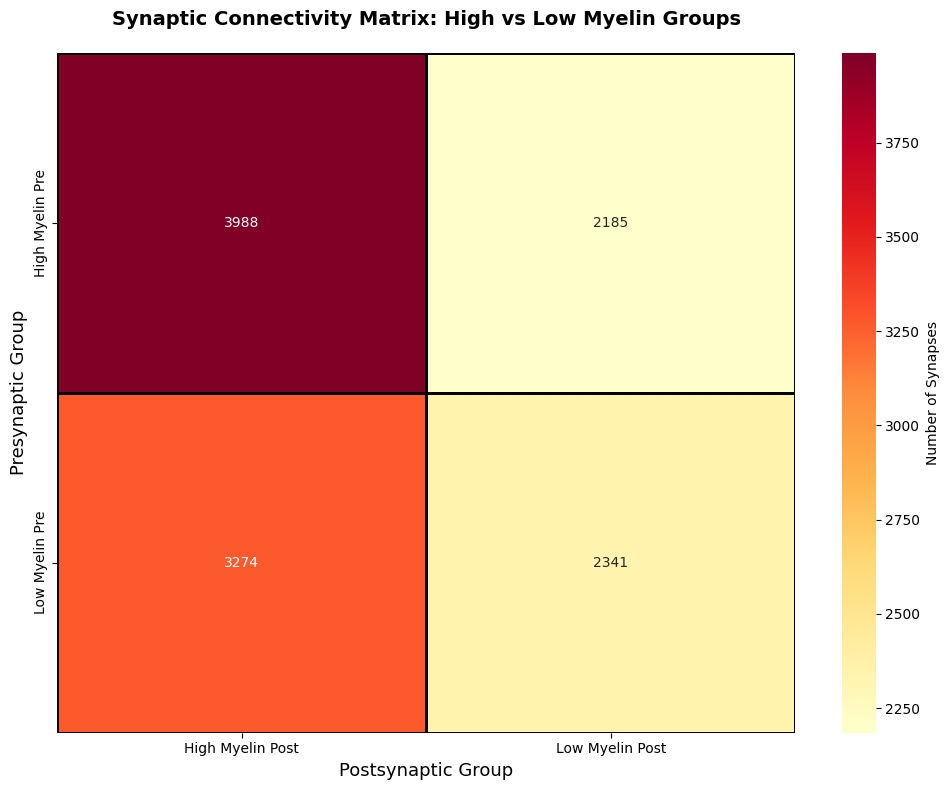

In [ ]:
# Connectivity matrix: High->High, High->Low, Low->High, Low->Low
connectivity_matrix = pd.DataFrame(index=['High Myelin Pre', 'Low Myelin Pre'],
                                   columns=['High Myelin Post', 'Low Myelin Post'])

# Total synapses
high_to_high = stats_df[stats_df['pre_myelin_group'] == 'high_myelin']['n_synapses_onto_high'].sum()
high_to_low = stats_df[stats_df['pre_myelin_group'] == 'high_myelin']['n_synapses_onto_low'].sum()
low_to_high = stats_df[stats_df['pre_myelin_group'] == 'low_myelin']['n_synapses_onto_high'].sum()
low_to_low = stats_df[stats_df['pre_myelin_group'] == 'low_myelin']['n_synapses_onto_low'].sum()

connectivity_matrix.loc['High Myelin Pre', 'High Myelin Post'] = high_to_high
connectivity_matrix.loc['High Myelin Pre', 'Low Myelin Post'] = high_to_low
connectivity_matrix.loc['Low Myelin Pre', 'High Myelin Post'] = low_to_high
connectivity_matrix.loc['Low Myelin Pre', 'Low Myelin Post'] = low_to_low

connectivity_matrix = connectivity_matrix.astype(int)

print("\nConnectivity Matrix (Total Synapses):")
print(connectivity_matrix)

# Plot as heatmap
fig, ax = plt.subplots(figsize=(10, 8))

sns.heatmap(connectivity_matrix.astype(int), annot=True, fmt='d', cmap='YlOrRd', 
            cbar_kws={'label': 'Number of Synapses'}, ax=ax, linewidths=2, linecolor='black')

ax.set_title('Synaptic Connectivity Matrix: High vs Low Myelin Groups', 
             fontsize=14, fontweight='bold', pad=20)
ax.set_xlabel('Postsynaptic Group', fontsize=13)
ax.set_ylabel('Presynaptic Group', fontsize=13)

plt.tight_layout()
plt.show()


Normalized Connectivity Matrix (Row-wise proportions):
                 High Myelin Post  Low Myelin Post
High Myelin Pre             0.876            0.124
Low Myelin Pre              0.846            0.154


/var/folders/20/sydjdg052fld_b2zzxcwvf540000gn/T/ipykernel_9125/1862723256.py:7: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.875711084295811' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  connectivity_matrix_norm.loc[idx] = connectivity_matrix_norm.loc[idx] / row_sum
/var/folders/20/sydjdg052fld_b2zzxcwvf540000gn/T/ipykernel_9125/1862723256.py:7: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.12428891570418893' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  connectivity_matrix_norm.loc[idx] = connectivity_matrix_norm.loc[idx] / row_sum


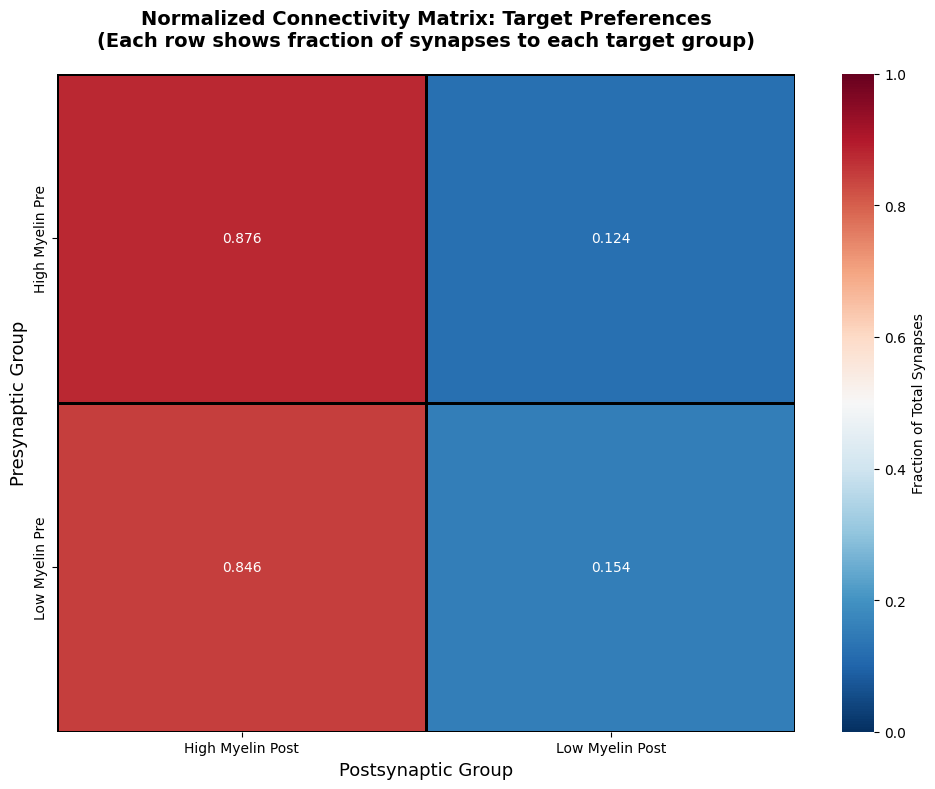

In [ ]:
# Normalized connectivity matrix (as fractions)
connectivity_matrix_norm = connectivity_matrix.copy()

# Normalize rows (each row sums to 1)
for idx in connectivity_matrix_norm.index:
    row_sum = connectivity_matrix_norm.loc[idx].sum()
    connectivity_matrix_norm.loc[idx] = connectivity_matrix_norm.loc[idx] / row_sum

print("\nNormalized Connectivity Matrix (Row-wise proportions):")
print(connectivity_matrix_norm.round(3))

# Plot normalized matrix
fig, ax = plt.subplots(figsize=(10, 8))

sns.heatmap(connectivity_matrix_norm, annot=True, fmt='.3f', cmap='RdBu_r', center=0.5,
            cbar_kws={'label': 'Fraction of Total Synapses'}, ax=ax, 
            linewidths=2, linecolor='black', vmin=0, vmax=1)

ax.set_title('Normalized Connectivity Matrix: Target Preferences\n(Each row shows fraction of synapses to each target group)', 
             fontsize=14, fontweight='bold', pad=20)
ax.set_xlabel('Postsynaptic Group', fontsize=13)
ax.set_ylabel('Presynaptic Group', fontsize=13)

plt.tight_layout()
plt.show()

In [ ]:
print("\n" + "="*80)
print("FINAL SUMMARY: MYELIN HOMOPHILY ANALYSIS")
print("="*80)

print(f"\n1. Dataset:")
print(f"   - Total excitatory neurons: {len(excitatory_df)}")
print(f"   - High myelin neurons: {len(high_myelin_neurons)} ({len(high_myelin_neurons)/len(excitatory_df)*100:.1f}%)")
print(f"   - Low myelin neurons: {len(low_myelin_neurons)} ({len(low_myelin_neurons)/len(excitatory_df)*100:.1f}%)")
print(f"   - Total synapses analyzed: {len(syn_df):,}")

print(f"\n2. Expected vs Observed (if connectivity were random):")
print(f"   - Expected fraction onto high myelin: {expected_frac:.3f}")
print(f"   - High myelin pre → high myelin post: {high_pre_fractions.mean():.3f} (diff: {high_pre_fractions.mean()-expected_frac:+.3f})")
print(f"   - Low myelin pre → high myelin post: {low_pre_fractions.mean():.3f} (diff: {low_pre_fractions.mean()-expected_frac:+.3f})")

print(f"\n3. Statistical Results:")
print(f"   - Mann-Whitney U test: p = {p_value:.6f} {sig}")

if p_value < 0.05:
    if high_mean > low_mean:
        fold_change = high_mean / low_mean
        print(f"   - HIGH MYELIN NEURONS show {fold_change:.2f}x preference for high myelin targets")
        print(f"   - This suggests POSITIVE HOMOPHILY (like connects to like)")
    else:
        fold_change = low_mean / high_mean
        print(f"   - LOW MYELIN NEURONS show {fold_change:.2f}x preference for high myelin targets")
        print(f"   - This suggests NEGATIVE HOMOPHILY (opposites attract)")
else:
    print(f"   - No significant homophily detected")
    print(f"   - Connectivity appears consistent with random wiring")

print(f"\n4. Connectivity Summary:")
high_to_high_total = stats_df[stats_df['pre_myelin_group'] == 'high_myelin']['n_synapses_onto_high'].sum()
high_to_low_total = stats_df[stats_df['pre_myelin_group'] == 'high_myelin']['n_synapses_onto_low'].sum()
low_to_high_total = stats_df[stats_df['pre_myelin_group'] == 'low_myelin']['n_synapses_onto_high'].sum()
low_to_low_total = stats_df[stats_df['pre_myelin_group'] == 'low_myelin']['n_synapses_onto_low'].sum()

high_total = high_to_high_total + high_to_low_total
low_total = low_to_high_total + low_to_low_total

print(f"   - High → High: {high_to_high_total:,} synapses ({high_to_high_total/high_total*100:.1f}%)")
print(f"   - High → Low: {high_to_low_total:,} synapses ({high_to_low_total/high_total*100:.1f}%)")
print(f"   - Low → High: {low_to_high_total:,} synapses ({low_to_high_total/low_total*100:.1f}%)")
print(f"   - Low → Low: {low_to_low_total:,} synapses ({low_to_low_total/low_total*100:.1f}%)")

print("\n" + "="*80)


FINAL SUMMARY: MYELIN HOMOPHILY ANALYSIS

1. Dataset:
   - Total excitatory neurons: 748
   - High myelin neurons: 374 (50.0%)
   - Low myelin neurons: 374 (50.0%)
   - Total synapses analyzed: 28,721

2. Expected vs Observed (if connectivity were random):
   - Expected fraction onto high myelin: 0.500
   - High myelin pre → high myelin post: 0.672 (diff: +0.172)
   - Low myelin pre → high myelin post: 0.584 (diff: +0.084)

3. Statistical Results:
   - Mann-Whitney U test: p = 0.000000 *** (p < 0.001)
   - HIGH MYELIN NEURONS show 1.15x preference for high myelin targets
   - This suggests POSITIVE HOMOPHILY (like connects to like)

4. Connectivity Summary:
   - High → High: 3,988 synapses (64.6%)
   - High → Low: 2,185 synapses (35.4%)
   - Low → High: 3,274 synapses (58.3%)
   - Low → Low: 2,341 synapses (41.7%)

